In [1]:
!date

Fri Sep 18 22:31:31 PDT 2026


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr, mannwhitneyu
import matplotlib.pyplot as plt

projdir = '/u/project/cluo/terencew/claude/project_ideas/pool_design'

In [3]:
### per-droplet scores with coverage columns (01e), joined to the chr22-matrix design metrics
### every ambisim/ pool was selected on
x = pd.read_csv(f'{projdir}/csv/ambisim/droplet_scores_cov.csv', sep='\t')
design = pd.read_csv(f'{projdir}/csv/designs/nominated_pools_n8.tsv', sep='\t')
design['pool'] = design['universe'] + '__' + design['strategy'] + '__rep' + design['rep'].astype(str)
design = design.drop_duplicates('pool')[['pool', 'min_dist', 'mean_dist', 'kl_min', 'kl_mean']]
x = x.merge(design, on='pool', how='left')
print('pools missing design metrics:', x['min_dist'].isna().sum())

pools missing design metrics: 0


In [4]:
x.head()

,pool,universe,strategy,rep,modality,barcode,is_true_singlet,called_singlet,correct,donor_correct,...,n_snps,n_reads_demux,true_reads,called_donor,true_donor,heldout,min_dist,mean_dist,kl_min,kl_mean
0,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACAACA,True,True,True,True,...,3232,3391,22915,HG02678,HG02678,False,104.52751,120.43151,1.886853,2.512456
1,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACATAG,True,True,True,True,...,4130,4488,30010,HG02816,HG02816,False,104.52751,120.43151,1.886853,2.512456
2,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACCCTA,True,True,True,True,...,2582,2843,19977,NA19922,NA19922,False,104.52751,120.43151,1.886853,2.512456
3,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACCTAT,True,True,True,True,...,718,741,5237,NA20274,NA20274,False,104.52751,120.43151,1.886853,2.512456
4,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACCTTG,True,True,True,True,...,6682,7458,51490,HG03136,HG03136,False,104.52751,120.43151,1.886853,2.512456


In [5]:
x.shape

(2303744, 25)

In [6]:
sng = x[x['is_true_singlet']]
called = x[x['is_true_singlet'] & x['called_singlet']]
ordinary_mask = ~x['strategy'].str.startswith('adversarial')
print(x['pool'].nunique(), 'pools;', (~x['strategy'].str.startswith('adversarial')).groupby(x['pool']).first().sum(), 'ordinary')

128 pools; 105 ordinary


In [7]:
### what the pool-level "singlet accuracy" number is actually made of. `correct` requires
### is_true_singlet & called_singlet & right donor -- so it multiplies two very different
### things together, and it turns out one of them is ~3 orders of magnitude noisier.
for mod in ['gex', 'atac']:
    t = sng[sng['modality'] == mod]
    p_sng = t['called_singlet'].mean()
    p_donor = t[t['called_singlet']]['donor_correct'].mean()
    print(f'{mod}: accuracy={t["correct"].mean():.4f} = P(called SNG)={p_sng:.4f} '
          f'x P(right donor | called SNG)={p_donor:.5f}')

gex: accuracy=0.8410 = P(called SNG)=0.8419 x P(right donor | called SNG)=0.99898
atac: accuracy=0.9170 = P(called SNG)=0.9170 x P(right donor | called SNG)=0.99995


In [8]:
### what demuxlet calls true singlets when it gets them wrong -- they go to DBL, not AMB,
### and the ones it loses are the ambient-heavy ones (ambient was fixed at 20% by simulation
### design and never swept, so this axis is a constant + noise, not something pool design moves)
for mod in ['gex', 'atac']:
    t = sng[sng['modality'] == mod]
    print(mod, dict(t['droplet_type'].value_counts(normalize=True).round(4)))
    mis, ok = t[~t['called_singlet']], t[t['called_singlet']]
    print(f'   called non-SNG (n={len(mis)}): ambient med={mis["ambient_frac"].median():.3f} '
          f'n_snps med={mis["n_snps"].median():.0f} sng_dbl_gap med={mis["sng_dbl_gap"].median():.2f}')
    print(f'   called SNG     (n={len(ok)}): ambient med={ok["ambient_frac"].median():.3f} '
          f'n_snps med={ok["n_snps"].median():.0f} sng_dbl_gap med={ok["sng_dbl_gap"].median():.2f}')

gex {'SNG': np.float64(0.8419), 'DBL': np.float64(0.1556), 'AMB': np.float64(0.0025)}
   called non-SNG (n=163904): ambient med=0.347 n_snps med=2362 sng_dbl_gap med=-5.32
   called SNG     (n=872768): ambient med=0.159 n_snps med=2790 sng_dbl_gap med=6.72
atac {'SNG': np.float64(0.917), 'DBL': np.float64(0.0829), 'AMB': np.float64(0.0001)}
   called non-SNG (n=86013): ambient med=0.408 n_snps med=4510 sng_dbl_gap med=-7.13
   called SNG     (n=950659): ambient med=0.167 n_snps med=6014 sng_dbl_gap med=19.43


In [9]:
### and the same split across pools: all of the pool-to-pool spread in "accuracy" is the
### singlet/doublet call. donor identity contributes essentially none of it.
for mod in ['gex', 'atac']:
    t = sng[(sng['modality'] == mod) & ~sng['strategy'].str.startswith('adversarial')]
    g = t.groupby('pool').agg(acc=('correct', 'mean'), p_sng=('called_singlet', 'mean'))
    g['p_donor'] = t[t['called_singlet']].groupby('pool')['donor_correct'].mean()
    print(f'{mod}: sd(accuracy)={g["acc"].std():.5f}  sd(P called SNG)={g["p_sng"].std():.5f}  '
          f'sd(P donor|SNG)={g["p_donor"].std():.6f}')

gex: sd(accuracy)=0.01069  sd(P called SNG)=0.01073  sd(P donor|SNG)=0.000427
atac: sd(accuracy)=0.00385  sd(P called SNG)=0.00385  sd(P donor|SNG)=0.000069


In [10]:
### pool-level table: accuracy, its two factors, margin, and design metrics
pool_tab = []
for mod in ['gex', 'atac']:
    t = sng[sng['modality'] == mod]
    g = t.groupby('pool').agg(acc=('correct', 'mean'), p_sng=('called_singlet', 'mean'),
                              universe=('universe', 'first'), strategy=('strategy', 'first'),
                              min_dist=('min_dist', 'first'), mean_dist=('mean_dist', 'first'),
                              kl_min=('kl_min', 'first'), heldout=('heldout', 'first'))
    cm = t[t['called_singlet']].groupby('pool')
    g['p_donor'] = cm['donor_correct'].mean()
    g['ll_gap_mean'] = cm['ll_gap'].mean()
    g['ll_gap_p5'] = cm['ll_gap'].quantile(0.05)
    g['n_snps_med'] = cm['n_snps'].median()
    g['err_per_1k'] = (1 - g['p_donor']) * 1000
    g['modality'] = mod
    pool_tab.append(g.reset_index())
pool_tab = pd.concat(pool_tab, ignore_index=True)

In [11]:
pool_tab.head()

,pool,acc,p_sng,universe,strategy,min_dist,mean_dist,kl_min,heldout,p_donor,ll_gap_mean,ll_gap_p5,n_snps_med,err_per_1k,modality
0,AFR_only__adversarial_mindist__rep1,0.825904,0.826769,AFR_only,adversarial_mindist,100.000000,103.623207,1.406993,False,0.998955,10.133407,-0.81,2784.0,1.045400,gex
1,AFR_only__adversarial_mindist__rep2,0.818373,0.818743,AFR_only,adversarial_mindist,99.779755,102.815285,1.382161,False,0.999548,9.803743,-0.82,2794.0,0.452420,gex
2,AFR_only__adversarial_mindist__rep3,0.837881,0.838375,AFR_only,adversarial_mindist,102.235023,104.529594,1.422913,True,0.999411,9.936954,-0.89,2790.0,0.589102,gex
3,AFR_only__greedy_maxkl__rep2,0.840598,0.841091,AFR_only,greedy_maxkl,112.565536,119.123520,1.678527,False,0.999413,10.150330,-0.78,2785.0,0.587199,gex
4,AFR_only__greedy_maxkl__rep3,0.821212,0.822324,AFR_only,greedy_maxkl,113.229858,119.638237,1.685390,True,0.998649,9.885719,-0.74,2762.5,1.351351,gex


In [12]:
pool_tab.shape

(256, 15)

In [13]:
### the null, rechecked. CONVENTIONS rules 1+2: adversarial-excluded and Spearman alongside
### Pearson. "heldout" = the 40 pools demuxed since the n=88 run RESULTS.md is written from,
### i.e. a replication set that was not used to make the original claim.
def report(sub, label, metric, geo='min_dist'):
    for mod in ['gex', 'atac']:
        d = sub[sub['modality'] == mod].dropna(subset=[geo])
        if len(d) < 10:
            continue
        r, pr = pearsonr(d[geo], d[metric])
        rho, ps = spearmanr(d[geo], d[metric])
        print(f'  {label:26s} {mod:4s} n={len(d):3d}  {geo} ~ {metric:11s} '
              f'r={r:+.3f}(p={pr:.4f})  rho={rho:+.3f}(p={ps:.4f})')

ordn = pool_tab[~pool_tab['strategy'].str.startswith('adversarial')]
for metric in ['acc', 'p_donor', 'p_sng', 'll_gap_mean']:
    print(f'--- {metric} ---')
    report(pool_tab, 'ALL (full sample)', metric)
    report(ordn, 'ORDINARY n=105', metric)
    report(ordn[~ordn['heldout']], 'ORDINARY re-analysis', metric)
    report(ordn[ordn['heldout']], 'ORDINARY HELD-OUT', metric)

--- acc ---
  ALL (full sample)          gex  n=128  min_dist ~ acc         r=+0.229(p=0.0093)  rho=+0.074(p=0.4033)
  ALL (full sample)          atac n=128  min_dist ~ acc         r=+0.515(p=0.0000)  rho=+0.343(p=0.0001)
  ORDINARY n=105             gex  n=105  min_dist ~ acc         r=-0.087(p=0.3754)  rho=-0.146(p=0.1370)
  ORDINARY n=105             atac n=105  min_dist ~ acc         r=+0.108(p=0.2737)  rho=+0.093(p=0.3469)
  ORDINARY re-analysis       gex  n= 73  min_dist ~ acc         r=-0.011(p=0.9253)  rho=-0.066(p=0.5782)
  ORDINARY re-analysis       atac n= 73  min_dist ~ acc         r=+0.101(p=0.3956)  rho=+0.085(p=0.4740)
  ORDINARY HELD-OUT          gex  n= 32  min_dist ~ acc         r=-0.225(p=0.2161)  rho=-0.312(p=0.0822)
  ORDINARY HELD-OUT          atac n= 32  min_dist ~ acc         r=+0.149(p=0.4164)  rho=+0.111(p=0.5469)
--- p_donor ---
  ALL (full sample)          gex  n=128  min_dist ~ p_donor     r=+0.582(p=0.0000)  rho=+0.341(p=0.0001)
  ALL (full sample)        

In [14]:
### donor-identity error rate by strategy, in errors per 1000 true singlets called SNG.
### the relative differences are large; the absolute ones are not.
pool_tab.groupby(['modality', 'strategy']).agg(n=('pool', 'nunique'), err_per_1k=('err_per_1k', 'mean'),
                                               ll_gap=('ll_gap_mean', 'mean')).round(4)

n  err_per_1k   ll_gap
modality strategy                                         
atac     adversarial_family         3      0.2266  18.2094
         adversarial_family_mixed   3      0.0908  19.7185
         adversarial_mindist       17      0.0873  25.5200
         ancestry_balanced         10      0.0403  28.5117
         greedy_maxkl              14      0.0384  25.0784
         greedy_maxmean            27      0.0399  28.2826
         greedy_maxmin             27      0.0448  28.2356
         random                    27      0.0250  27.1882
gex      adversarial_family         3      3.2763   6.6394
         adversarial_family_mixed   3      2.6136   7.4183
         adversarial_mindist       17      1.1949   9.0020
         ancestry_balanced         10      0.7304  10.5116
         greedy_maxkl              14      1.2236   8.9771
         greedy_maxmean            27      0.8299  10.2552
         greedy_maxmin             27      0.8160  10.2680
         random                    27      0.8722   9.8131

In [15]:
### CALIBRATION CURVE: P(right donor) as a function of ll_gap, pooled over all pools.
### CAREFUL what ll_gap is: DIFF.LLK.BEST.NEXT. For a droplet demuxlet calls SNG, NEXT.GUESS is
### a doublet model in 6705/6706 cases, so this column equals DIFF.LLK.SNG.DBL -- it is the
### singlet-vs-doublet margin, NOT the donor-vs-donor margin. The donor-discrimination margin is
### SNG.BEST.LLK - SNG.NEXT.LLK (the sng_gap column), analysed in 01g. Both curves are real;
### this one just answers a different question than its name suggests.
edges = [-5, 0, 0.5, 1, 2, 3, 5, 7.5, 10, 15, 20, 30, 50, 75, 100, 150, 250, np.inf]
curve = []
for mod in ['gex', 'atac']:
    d = called[called['modality'] == mod].copy()
    d['bin'] = pd.cut(d['ll_gap'], edges, right=False)
    g = d.groupby('bin', observed=True).agg(n=('donor_correct', 'size'), acc=('donor_correct', 'mean'),
                                            med_snps=('n_snps', 'median')).reset_index()
    g['frac'] = g['n'] / g['n'].sum()
    g['cum_frac'] = g['frac'].cumsum()
    g['modality'] = mod
    curve.append(g)
    print(f'--- {mod} ---')
    print(g.to_string(index=False, float_format=lambda v: f'{v:.5f}'))
curve = pd.concat(curve, ignore_index=True)

--- gex ---
           bin      n     acc    med_snps    frac  cum_frac modality
   [-5.0, 0.0)  77626 0.99176  1791.00000 0.08894   0.08894      gex
    [0.0, 0.5)  24273 0.99497  1714.00000 0.02781   0.11675      gex
    [0.5, 1.0)  25604 0.99762  1713.00000 0.02934   0.14609      gex
    [1.0, 2.0)  54862 0.99929  1728.00000 0.06286   0.20895      gex
    [2.0, 3.0)  57716 0.99958  1791.50000 0.06613   0.27508      gex
    [3.0, 5.0) 111299 0.99998  1993.00000 0.12752   0.40260      gex
    [5.0, 7.5) 119030 1.00000  2340.00000 0.13638   0.53899      gex
   [7.5, 10.0)  93015 1.00000  2761.00000 0.10657   0.64556      gex
  [10.0, 15.0) 125280 1.00000  3409.00000 0.14354   0.78910      gex
  [15.0, 20.0)  71279 1.00000  4311.00000 0.08167   0.87077      gex
  [20.0, 30.0)  67452 1.00000  5598.00000 0.07729   0.94806      gex
  [30.0, 50.0)  36572 1.00000  7710.50000 0.04190   0.98996      gex
  [50.0, 75.0)   7267 1.00000 10939.00000 0.00833   0.99829      gex
 [75.0, 100.0)   1042 

In [16]:
### same thing on the coverage axis, plus the reads <-> SNPs <-> LL-gap translation an
### experimentalist would actually use
sedge = [0, 400, 700, 1000, 1500, 2000, 3000, 5000, 8000, np.inf]
covtab = []
for mod in ['gex', 'atac']:
    d = called[called['modality'] == mod].copy()
    d['bin'] = pd.cut(d['n_snps'], sedge, right=False)
    g = d.groupby('bin', observed=True).agg(n=('donor_correct', 'size'), acc=('donor_correct', 'mean'),
                                            med_reads=('true_reads', 'median'),
                                            med_llgap=('ll_gap', 'median'),
                                            p5_llgap=('ll_gap', lambda v: np.percentile(v, 5))).reset_index()
    g['frac'] = g['n'] / g['n'].sum()
    g['modality'] = mod
    covtab.append(g)
    print(f'--- {mod} ---')
    print(g.to_string(index=False, float_format=lambda v: f'{v:.5f}'))
covtab = pd.concat(covtab, ignore_index=True)

--- gex ---
             bin      n     acc   med_reads  med_llgap  p5_llgap    frac modality
    [0.0, 400.0)    724 0.92541  2575.00000    0.80000  -1.20000 0.00083      gex
  [400.0, 700.0)  11303 0.97018  4322.00000    0.98000  -1.45000 0.01295      gex
 [700.0, 1000.0)  37415 0.99139  6018.00000    1.55000  -1.47000 0.04287      gex
[1000.0, 1500.0) 100871 0.99854  9022.00000    2.60000  -1.33000 0.11558      gex
[1500.0, 2000.0) 114538 0.99980 12613.00000    3.92000  -1.14000 0.13124      gex
[2000.0, 3000.0) 210337 0.99998 18055.00000    6.16000  -0.77000 0.24100      gex
[3000.0, 5000.0) 236547 1.00000 28208.00000   10.48000   0.01000 0.27103      gex
[5000.0, 8000.0) 117545 1.00000 46512.00000   18.86000   1.59000 0.13468      gex
   [8000.0, inf)  43488 1.00000 78901.00000   33.21000   5.56000 0.04983      gex
--- atac ---
             bin      n     acc   med_reads  med_llgap  p5_llgap    frac modality
    [0.0, 400.0)     78 0.92308  1284.00000    0.48500  -1.68100 0.00008 

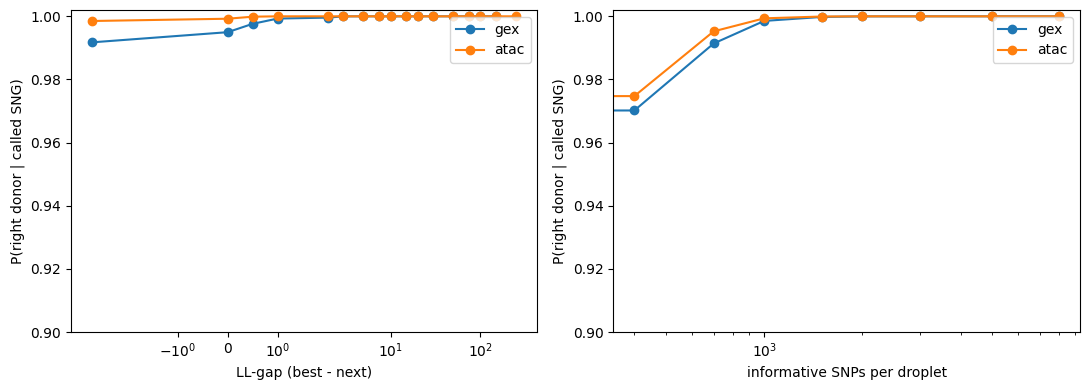

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for mod, col in [('gex', 'C0'), ('atac', 'C1')]:
    g = curve[curve['modality'] == mod]
    xs = [iv.left for iv in g['bin']]
    axes[0].plot(xs, g['acc'], 'o-', color=col, label=mod)
    g2 = covtab[covtab['modality'] == mod]
    axes[1].plot([iv.left for iv in g2['bin']], g2['acc'], 'o-', color=col, label=mod)
axes[0].set_xscale('symlog'); axes[0].set_xlabel('LL-gap (best - next)')
axes[1].set_xscale('log'); axes[1].set_xlabel('informative SNPs per droplet')
for a in axes:
    a.set_ylabel('P(right donor | called SNG)'); a.set_ylim(0.9, 1.002); a.legend()
plt.tight_layout()
plt.show()

In [18]:
### COVERAGE-MATCHED, apples to apples: inside each n_snps bin, does min_dist still predict
### the margin, and does it predict either half of accuracy? ordinary pools only.
matched = []
for mod in ['gex', 'atac']:
    t = sng[(sng['modality'] == mod) & ~sng['strategy'].str.startswith('adversarial')].copy()
    t['cov_bin'] = pd.cut(t['n_snps'], sedge, right=False)
    for cb, d in t.groupby('cov_bin', observed=True):
        pp = d.groupby('pool').agg(n=('correct', 'size'), p_sng=('called_singlet', 'mean'),
                                   llgap=('ll_gap', 'mean'), min_dist=('min_dist', 'first'))
        pp['p_donor'] = d[d['called_singlet']].groupby('pool')['donor_correct'].mean()
        pp = pp[pp['n'] >= 200]
        if len(pp) < 20:
            continue
        row = dict(modality=mod, cov_bin=str(cb), n_pools=len(pp), n_droplets=len(d),
                   llgap=pp['llgap'].mean(), p_sng=pp['p_sng'].mean(), p_donor=pp['p_donor'].mean())
        for tgt in ['llgap', 'p_sng', 'p_donor']:
            v = pp[tgt].fillna(1)
            row[f'rho_{tgt}'], row[f'p_{tgt}'] = spearmanr(pp['min_dist'], v) if v.nunique() > 1 else (np.nan, np.nan)
        matched.append(row)
matched = pd.DataFrame(matched)
print(matched.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

modality          cov_bin  n_pools  n_droplets   llgap  p_sng  p_donor  rho_llgap  p_llgap  rho_p_sng  p_p_sng  rho_p_donor  p_p_donor
     gex  [700.0, 1000.0)      105       38965  1.3397 0.7899   0.9928     0.2317   0.0174     0.0739   0.4540       0.1375     0.1619
     gex [1000.0, 1500.0)      105      102506  2.2994 0.8093   0.9989     0.2781   0.0041    -0.0478   0.6279       0.0464     0.6386
     gex [1500.0, 2000.0)      105      114814  3.4774 0.8201   0.9999     0.3054   0.0015    -0.1026   0.2978       0.0335     0.7345
     gex [2000.0, 3000.0)      105      206844  5.5152 0.8362   1.0000     0.2991   0.0019    -0.0683   0.4885       0.0761     0.4401
     gex [3000.0, 5000.0)      105      226402  9.5650 0.8586   1.0000     0.2961   0.0022    -0.1856   0.0581          NaN        NaN
     gex [5000.0, 8000.0)      105      109129 17.3007 0.8846   1.0000     0.2940   0.0023    -0.1615   0.0998          NaN        NaN
     gex    [8000.0, inf)      105       38300 33.4524 

In [19]:
### the same comparison the strategy labels make, held at matched coverage. NOTE: per
### RESULTS.md section 6, greedy_maxmin vs greedy_maxmean is NOT a min-vs-mean test here --
### those two share 5-6/8 donors and their min/mean distances correlate 0.69-0.84. Read this
### as random vs optimized vs adversarial, not as min vs mean.
keep = ['random', 'greedy_maxmin', 'greedy_maxmean', 'ancestry_balanced', 'adversarial_mindist']
t = sng[sng['strategy'].isin(keep)].copy()
t['cov_bin'] = pd.cut(t['n_snps'], sedge, right=False)
for mod in ['gex', 'atac']:
    d = t[t['modality'] == mod]
    print(f'--- {mod}: mean LL-gap ---')
    print(d.pivot_table(index='cov_bin', columns='strategy', values='ll_gap',
                        aggfunc='mean', observed=True)[keep].to_string(float_format=lambda v: f'{v:.2f}'))
    print(f'--- {mod}: P(right donor | called SNG) ---')
    print(d[d['called_singlet']].pivot_table(index='cov_bin', columns='strategy', values='donor_correct',
                                             aggfunc='mean', observed=True)[keep].to_string(float_format=lambda v: f'{v:.5f}'))
    print(f'--- {mod}: P(called SNG) ---')
    print(d.pivot_table(index='cov_bin', columns='strategy', values='called_singlet',
                        aggfunc='mean', observed=True)[keep].to_string(float_format=lambda v: f'{v:.4f}'))

--- gex: mean LL-gap ---
strategy          random  greedy_maxmin  greedy_maxmean  ancestry_balanced  adversarial_mindist
cov_bin                                                                                        
[0.0, 400.0)        0.55           0.55            0.50               0.72                 0.49
[400.0, 700.0)      0.80           0.76            0.82               0.84                 0.71
[700.0, 1000.0)     1.28           1.38            1.41               1.45                 1.15
[1000.0, 1500.0)    2.24           2.36            2.38               2.51                 2.00
[1500.0, 2000.0)    3.38           3.59            3.59               3.75                 3.04
[2000.0, 3000.0)    5.39           5.66            5.69               5.84                 4.83
[3000.0, 5000.0)    9.38           9.83            9.81              10.10                 8.51
[5000.0, 8000.0)   17.01          17.78           17.67              18.14                15.54
[8000.0, inf)  

In [20]:
### is the LL-gap a sufficient statistic for accuracy? if it is, pools differ only in where
### they sit on the one curve above, not in the curve itself -- and then the whole design
### question reduces to "does the design move the LL-gap distribution far enough to matter".
gedge = [-5, 1, 2, 3, 5, 10, np.inf]
glab = ['<1', '1-2', '2-3', '3-5', '5-10', '>10']
d = called[called['strategy'].isin(keep)].copy()
d['gap_bin'] = pd.cut(d['ll_gap'], gedge, labels=glab, right=False)
for mod in ['gex', 'atac']:
    dd = d[d['modality'] == mod]
    print(f'--- {mod} P(right donor) by LL-gap bin x strategy ---')
    print(dd.pivot_table(index='gap_bin', columns='strategy', values='donor_correct',
                         aggfunc='mean', observed=True)[keep].to_string(float_format=lambda v: f'{v:.5f}'))

--- gex P(right donor) by LL-gap bin x strategy ---
strategy  random  greedy_maxmin  greedy_maxmean  ancestry_balanced  adversarial_mindist
gap_bin                                                                                
<1       0.99435        0.99457         0.99443            0.99529              0.99274
1-2      0.99956        0.99937         0.99936            0.99870              0.99949
2-3      0.99975        0.99965         0.99966            0.99953              0.99952
3-5      0.99992        1.00000         1.00000            1.00000              1.00000
5-10     1.00000        1.00000         1.00000            1.00000              1.00000
>10      1.00000        1.00000         1.00000            1.00000              1.00000
--- atac P(right donor) by LL-gap bin x strategy ---
strategy  random  greedy_maxmin  greedy_maxmean  ancestry_balanced  adversarial_mindist
gap_bin                                                                                
<1       0.9994

In [21]:
### so: where do the pools actually differ? in the fraction of droplets that land below the
### threshold. that fraction does track min_dist -- it just lands where the curve is flat.
thr = {'gex': 3.0, 'atac': 1.0}
for mod in ['gex', 'atac']:
    d = called[called['modality'] == mod]
    pp = d.groupby('pool').agg(sub=('ll_gap', lambda v: (v < thr[mod]).mean()),
                               min_dist=('min_dist', 'first'), strategy=('strategy', 'first'))
    o = pp[~pp['strategy'].str.startswith('adversarial')]
    rho, p = spearmanr(o['min_dist'], o['sub'])
    print(f'{mod}: frac(ll_gap < {thr[mod]}) mean={pp["sub"].mean():.4f} '
          f'range={pp["sub"].min():.4f}-{pp["sub"].max():.4f}; vs min_dist (ordinary n={len(o)}) '
          f'rho={rho:+.3f} p={p:.4f}')

gex: frac(ll_gap < 3.0) mean=0.2752 range=0.2240-0.3730; vs min_dist (ordinary n=105) rho=-0.272 p=0.0050
atac: frac(ll_gap < 1.0) mean=0.0457 range=0.0349-0.0674; vs min_dist (ordinary n=105) rho=-0.234 p=0.0164


In [22]:
### LOW-COVERAGE STRATUM -- the downsampling question, asked of the droplets the simulation
### already produced instead of re-running demuxlet on subsampled BAMs
lowcov = []
for mod in ['gex', 'atac']:
    for lo, hi in [(0, 700), (700, 1200), (1200, 2000), (2000, np.inf)]:
        d = called[(called['modality'] == mod) & (called['n_snps'] >= lo) & (called['n_snps'] < hi)]
        if len(d) < 5000:
            continue
        pp = d.groupby('pool').agg(n=('donor_correct', 'size'), acc=('donor_correct', 'mean'),
                                   llgap=('ll_gap', 'mean'), min_dist=('min_dist', 'first'),
                                   strategy=('strategy', 'first'))
        pp = pp[pp['n'] >= 100]
        o = pp[~pp['strategy'].str.startswith('adversarial')]
        adv = pp[pp['strategy'].str.startswith('adversarial')]
        rho_a, p_a = spearmanr(o['min_dist'], o['acc'])
        rho_g, p_g = spearmanr(o['min_dist'], o['llgap'])
        u, p_u = mannwhitneyu(adv['acc'], o['acc'], alternative='less') if len(adv) > 2 else (np.nan, np.nan)
        lowcov.append(dict(modality=mod, lo=lo, hi=hi, n_pools=len(pp), n_droplets=len(d),
                           acc_ordinary=o['acc'].mean(), acc_adversarial=adv['acc'].mean(),
                           mwu_p=p_u, rho_min_dist_acc=rho_a, p_acc=p_a,
                           rho_min_dist_llgap=rho_g, p_llgap=p_g))
lowcov = pd.DataFrame(lowcov)
print(lowcov.to_string(index=False, float_format=lambda v: f'{v:.5f}'))

modality   lo         hi  n_pools  n_droplets  acc_ordinary  acc_adversarial   mwu_p  rho_min_dist_acc   p_acc  rho_min_dist_llgap  p_llgap
     gex    0  700.00000       26       12027       0.97180          0.99010     NaN           0.11055 0.60706             0.15090  0.48153
     gex  700 1200.00000      128       72261       0.99512          0.98895 0.00005           0.11053 0.26166             0.28726  0.00297
     gex 1200 2000.00000      128      180563       0.99980          0.99903 0.00025           0.02207 0.82315             0.31057  0.00126
     gex 2000        inf      128      607917       1.00000          0.99997 0.00565           0.07614 0.44012             0.32798  0.00064
    atac  700 1200.00000        0        8035           NaN              NaN     NaN               NaN     NaN                 NaN      NaN
    atac 1200 2000.00000      128       42305       0.99991          0.99934 0.00086          -0.11830 0.22937             0.24796  0.01076
    atac 2000       

/tmp/ipykernel_60625/4027098405.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_a, p_a = spearmanr(o['min_dist'], o['acc'])


In [23]:
### and the same stratification for the family pools, which are the one design choice that
### has been shown to move accuracy
for mod in ['gex', 'atac']:
    for lo, hi in [(0, 700), (700, 1200), (1200, 2000), (2000, np.inf)]:
        d = called[(called['modality'] == mod) & (called['n_snps'] >= lo) & (called['n_snps'] < hi)]
        fam = d[d['strategy'].str.startswith('adversarial_family')]
        mind = d[d['strategy'] == 'adversarial_mindist']
        o = d[~d['strategy'].str.startswith('adversarial')]
        if len(fam) < 200:
            continue
        print(f'{mod} n_snps[{lo},{hi}) ordinary={o["donor_correct"].mean():.5f} (n={len(o)})  '
              f'mindist={mind["donor_correct"].mean():.5f} (n={len(mind)})  '
              f'family={fam["donor_correct"].mean():.5f} (n={len(fam)})')

gex n_snps[0,700) ordinary=0.96882 (n=9942)  mindist=0.96671 (n=1562)  family=0.94455 (n=523)
gex n_snps[700,1200) ordinary=0.99512 (n=59406)  mindist=0.99189 (n=9622)  family=0.98051 (n=3233)
gex n_snps[1200,2000) ordinary=0.99980 (n=148487)  mindist=0.99966 (n=23733)  family=0.99724 (n=8343)
gex n_snps[2000,inf) ordinary=1.00000 (n=499625)  mindist=1.00000 (n=80279)  family=0.99989 (n=28013)
atac n_snps[700,1200) ordinary=0.99818 (n=6590)  mindist=0.99448 (n=1087)  family=0.99162 (n=358)
atac n_snps[1200,2000) ordinary=0.99991 (n=34710)  mindist=0.99982 (n=5618)  family=0.99798 (n=1977)
atac n_snps[2000,inf) ordinary=1.00000 (n=738883)  mindist=1.00000 (n=119159)  family=1.00000 (n=41724)


In [24]:
### what would a real downsampling run find? shrink every droplet's LL-gap by lambda and push
### it back through the empirical curve above (valid because the previous cell showed the curve
### is shared across strategies). lambda ~ the read-depth factor, since LL-gap scales roughly
### linearly with informative SNPs.
def build_curve(d, nbin=400):
    edges = np.unique(np.quantile(d['ll_gap'], np.linspace(0, 1, nbin + 1)))
    idx = np.clip(np.searchsorted(edges, d['ll_gap'], 'right') - 1, 0, len(edges) - 2)
    acc = pd.Series(d['donor_correct'].values).groupby(idx).mean().reindex(range(len(edges) - 1)).ffill().bfill().values
    ctr = pd.Series(d['ll_gap'].values).groupby(idx).mean().reindex(range(len(edges) - 1)).ffill().bfill().values
    return ctr, np.minimum.accumulate(acc[::-1])[::-1]

proj = []
for mod in ['gex', 'atac']:
    d = called[called['modality'] == mod]
    gx, gy = build_curve(d)
    gl = d.groupby('pool')['ll_gap'].apply(np.array)
    md = d.groupby('pool')['min_dist'].first()
    st = d.groupby('pool')['strategy'].first()
    ok = ~st.str.startswith('adversarial')
    for lam in [1.0, 0.5, 0.3, 0.2, 0.15, 0.1, 0.07, 0.05, 0.03]:
        acc = pd.Series({k: np.interp(v * lam, gx, gy).mean() for k, v in gl.items()})
        proj.append(dict(modality=mod, lam=lam, mean_acc=acc.mean(), sd_acc=acc.std(),
                         acc_min=acc.min(), acc_max=acc.max(),
                         ordinary_minus_advmindist=acc[ok].mean() - acc[st == 'adversarial_mindist'].mean(),
                         ordinary_minus_family=acc[ok].mean() - acc[st.str.startswith('adversarial_family')].mean()))
proj = pd.DataFrame(proj)
print(proj.to_string(index=False, float_format=lambda v: f'{v:.5f}'))

modality     lam  mean_acc  sd_acc  acc_min  acc_max  ordinary_minus_advmindist  ordinary_minus_family
     gex 1.00000   0.99847 0.00018  0.99791  0.99877                    0.00014                0.00046
     gex 0.50000   0.99802 0.00022  0.99735  0.99838                    0.00018                0.00059
     gex 0.30000   0.99740 0.00025  0.99666  0.99781                    0.00021                0.00067
     gex 0.20000   0.99674 0.00027  0.99597  0.99717                    0.00022                0.00071
     gex 0.15000   0.99622 0.00027  0.99546  0.99665                    0.00022                0.00070
     gex 0.10000   0.99547 0.00026  0.99473  0.99588                    0.00022                0.00068
     gex 0.07000   0.99482 0.00025  0.99413  0.99522                    0.00020                0.00064
     gex 0.05000   0.99424 0.00022  0.99362  0.99460                    0.00018                0.00057
     gex 0.03000   0.99347 0.00017  0.99301  0.99375                    0

In [25]:
### NOTE on reading the projection: the between-pool spread it shows is inherited from each
### pool's LL-gap distribution, so it is not independent evidence that design predicts accuracy.
### What it is good for is magnitude -- even a 30x margin shrink leaves mean donor accuracy above
### 0.99, so the ordinary-pool null is not something a downsampling run is likely to overturn.
outdir = f'{projdir}/csv/ambisim'
pool_tab.to_csv(f'{outdir}/pool_summary_n128.csv', sep='\t', index=False)
curve.to_csv(f'{outdir}/llgap_accuracy_curve.csv', sep='\t', index=False)
covtab.to_csv(f'{outdir}/coverage_accuracy_curve.csv', sep='\t', index=False)
matched.to_csv(f'{outdir}/coverage_matched_design.csv', sep='\t', index=False)
lowcov.to_csv(f'{outdir}/lowcov_stratum.csv', sep='\t', index=False)
proj.to_csv(f'{outdir}/margin_shrink_projection.csv', sep='\t', index=False)

In [26]:
!date

Fri Sep 18 22:32:04 PDT 2026
